In [1]:
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
from pathlib import Path
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
DATA_DIR_FILENAME = Path("/home/nbyrnes/code/random-matrix/paper_data/data")
MODE_GRIDS_FILENAME = Path(
    "/home/nbyrnes/code/random-matrix/paper_data/mode_grids_rectangular.pkl"
)
TWO_NP_PREAMBLE = "2d_np_rectangular_midpoint_"

if MODE_GRIDS_FILENAME.exists():
    # Load existing mode grids
    with MODE_GRIDS_FILENAME.open("rb") as f:
        mode_grids = pickle.load(f)
        num_modes = [m.num_propagating for m in mode_grids]

two_np_path = DATA_DIR_FILENAME / f"{TWO_NP_PREAMBLE}{793}/integration_result_list.pkl"


if two_np_path.exists():
    with two_np_path.open("rb") as f:
        results = pickle.load(f)
grid = mode_grids[7]

In [3]:
wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

# 2D version
particle_statistics_2d = ParticleStatistics(
    term,
    isotropic_sphere.get_A,
    isotropic_sphere.get_A_product,
    isotropic_sphere.get_A_product_conj,
)
medium_statistics_2d = MediumStatistics([particle_statistics_2d])

# Non GPU Config
use_np_config = IntegrationTaskConfig(use_gpu=False)


num_modes = grid.num_propagating
print(f"Starting num_modes = {num_modes}")
# 2D
simulation_name = f"2d_np_rectangular_midpoint_{num_modes}"
input_statistics_manager_2d = InputStatisticsManager(
    simulation_name,
    medium_parameters,
    medium_statistics_2d,
    grid,
    parent_data_dir=DATA_DIR_FILENAME,
    supplied_indices=None,
    use_dirac_density=False,
    integration_method="midpoint",
    covariance_cubature_scheme=None,
    integration_task_config=use_np_config,
)


Starting num_modes = 793


In [4]:
integration_result_list = results

mean_result_list = integration_result_list.by_statistic_type("mean")
cov_result_list = integration_result_list.by_statistic_type(
    "covariance"
)
pseudo_cov_result_list = integration_result_list.by_statistic_type(
    "pseudo_covariance"
)


In [ ]:
mean_S = input_statistics_manager_2d._get_mean_S(mean_result_list)

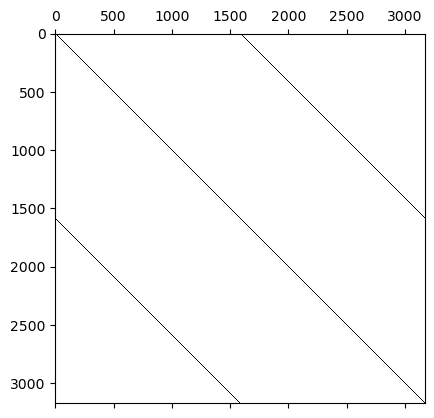

In [10]:
plt.spy(mean_S)

In [11]:
cov = input_statistics_manager_2d._get_covariance_matrix(cov_result_list)

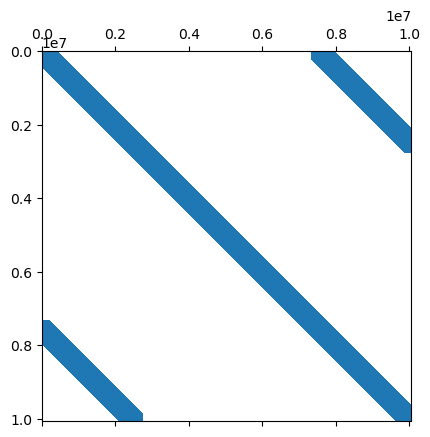

In [17]:
plt.spy(cov)

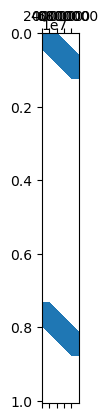

In [25]:
plt.spy(cov[:, 0:1000000])

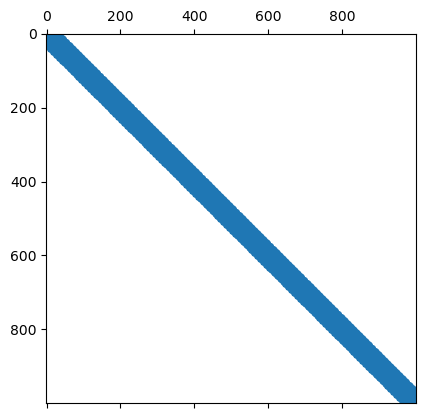

In [16]:
plt.spy(cov[0:1000,0:1000])

In [27]:
cov.shape

(10061584, 10061584)

In [18]:
sigma = 0.5 * scipy.sparse.bmat(
    [
        [np.real(cov ), np.imag(-cov )],
        [np.imag(cov ), np.real(cov )],
    ]
)


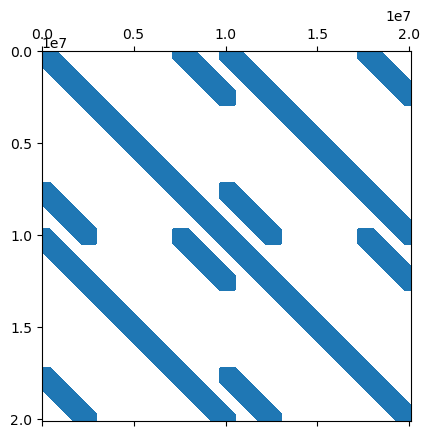

In [28]:
plt.spy(sigma)